# Baseline vs MAS Analysis

Cells 0–8. Only includes "normally-ended" runs: `max_floor >= 2` and `total_steps >= 30`.

Kept: **bl_01, bl_02, bl_test3, bl_test4, bl_test6** (baseline) · **mas_02, mas_03** (mas).

Dropped: `mas_01` (steps.jsonl was overwritten by later short run — only 7 lines left), plus all short/opening-death runs.

In [1]:
# Cell 0 — imports + config
import json, glob, os
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RUNS_DIR  = Path('runs')
MIN_FLOOR = 2      # must reach floor >= 2 (no opening-death)
MIN_STEPS = 80     # must have >= 80 decision steps (no short/abandoned runs)
EXCLUDE   = {'mas_01'}  # jsonl was overwritten by a later short run, only 7 lines remain

SYS_COLOR = {'baseline': '#1f77b4', 'mas': '#d62728'}
plt.rcParams['figure.dpi'] = 110

In [2]:
# Cell 1 — load + filter runs
def load_run(run_id: str):
    steps_p = RUNS_DIR / f'{run_id}_steps.jsonl'
    sum_p   = RUNS_DIR / f'{run_id}_summary.json'
    steps = [json.loads(l) for l in steps_p.open() if l.strip()] if steps_p.exists() else []
    summary = json.load(sum_p.open()) if sum_p.exists() else {}
    floors = [s.get('floor') for s in steps if s.get('floor') is not None]
    hps    = [s.get('hp')    for s in steps if s.get('hp')    is not None]
    return {
        'run_id':           run_id,
        'system':           summary.get('system') or ('mas' if run_id.startswith('mas') else 'baseline'),
        'model':            summary.get('model'),
        'total_steps':      len(steps),
        'wall_seconds':     summary.get('wall_seconds'),
        'max_floor':        max(floors) if floors else None,
        'last_hp':          steps[-1].get('hp') if steps else None,
        'min_hp':           min(hps) if hps else None,
        'last_gold':        steps[-1].get('gold') if steps else None,
        'final_state_type': summary.get('final_state_type'),
        'won':              bool(summary.get('won')),
        'steps':            steps,
    }

all_ids = sorted({p.stem.replace('_steps','') for p in RUNS_DIR.glob('*_steps.jsonl')})
runs = [load_run(rid) for rid in all_ids]
kept = [r for r in runs
        if r['run_id'] not in EXCLUDE
        and (r['max_floor'] or 0) >= MIN_FLOOR
        and r['total_steps'] >= MIN_STEPS]

print(f'kept {len(kept)} of {len(runs)} runs')
for r in kept:
    print(f"  {r['run_id']:>10} | {r['system']:<8} | steps={r['total_steps']:>4} | max_floor={r['max_floor']:>2} | last_hp={r['last_hp']}")

kept 5 of 21 runs
       bl_01 | baseline | steps=  98 | max_floor= 6 | last_hp=3
       bl_02 | baseline | steps=  89 | max_floor= 3 | last_hp=74
    bl_test6 | baseline | steps=  92 | max_floor= 5 | last_hp=52
      mas_02 | mas      | steps= 207 | max_floor=15 | last_hp=14
      mas_03 | mas      | steps= 223 | max_floor=15 | last_hp=15


In [3]:
# Cell 2 — flatten into df_steps (one row per decision)
def tool_key(a):
    a = a or {}
    return (a.get('tool'), json.dumps(a.get('params') or {}, sort_keys=True))

records = []
for r in kept:
    for s in r['steps']:
        chosen = s.get('chosen') or {}
        proposals = s.get('proposals') or {}
        ckey = tool_key(chosen)
        chosen_agent = None
        for name, p in proposals.items():
            if tool_key(p.get('action')) == ckey:
                chosen_agent = name; break
        # detect LLM-error noop steps (used later)
        any_just = ' '.join((p.get('justification') or '') for p in proposals.values())
        llm_error = ('LLM error' in any_just) or ('LLMProxy error' in any_just)
        row = {
            'run_id':       r['run_id'],
            'system':       r['system'],
            'step':         s.get('step'),
            't':            s.get('t'),
            'state_type':   s.get('state_type'),
            'floor':        s.get('floor'),
            'hp':           s.get('hp'),
            'gold':         s.get('gold'),
            'chosen_tool':  chosen.get('tool'),
            'chosen_agent': chosen_agent,
            'agreement':    s.get('agreement'),
            'llm_error':    llm_error,
        }
        for name, p in proposals.items():
            row[f'{name}_tool'] = (p.get('action') or {}).get('tool')
            row[f'{name}_conf'] = p.get('confidence')
        records.append(row)

df_steps   = pd.DataFrame(records)
df_summary = pd.DataFrame([{k:v for k,v in r.items() if k != 'steps'} for r in kept])
print('df_steps:',   df_steps.shape, '· columns:', list(df_steps.columns))
print('df_summary:', df_summary.shape)
df_summary

df_steps: (709, 20) · columns: ['run_id', 'system', 'step', 't', 'state_type', 'floor', 'hp', 'gold', 'chosen_tool', 'chosen_agent', 'agreement', 'llm_error', 'baseline_tool', 'baseline_conf', 'combat_tool', 'combat_conf', 'strategic_tool', 'strategic_conf', 'economy_tool', 'economy_conf']
df_summary: (5, 11)


,run_id,system,model,total_steps,wall_seconds,max_floor,last_hp,min_hp,last_gold,final_state_type,won
0,bl_01,baseline,4o-mini,98,456.4,6,3,3,129,menu,False
1,bl_02,baseline,4o-mini,89,530.1,3,74,74,115,NaN,False
2,bl_test6,baseline,4o-mini,92,485.1,5,52,52,129,NaN,False
3,mas_02,mas,4o-mini,207,1044.1,15,14,14,292,overlay,False
4,mas_03,mas,NaN,223,NaN,15,15,7,358,NaN,False


In [4]:
# Cell 3 — run-level outcome table
tbl = df_summary[['run_id','system','total_steps','wall_seconds','max_floor',
                  'last_hp','min_hp','last_gold','final_state_type','won']].copy()
tbl['sec_per_step'] = (tbl['wall_seconds'] / tbl['total_steps']).round(2)
tbl = tbl.sort_values(['system','max_floor'], ascending=[True, False]).reset_index(drop=True)

print('\n== Per-run outcomes ==')
print(tbl.to_string(index=False))
print('\n== Group means ==')
grp = df_summary.groupby('system').agg(
    n=('run_id','count'),
    steps_mean=('total_steps','mean'),
    floor_mean=('max_floor','mean'),
    floor_max=('max_floor','max'),
    wall_mean=('wall_seconds','mean'),
).round(1)
print(grp.to_string())


== Per-run outcomes ==
  run_id   system  total_steps  wall_seconds  max_floor  last_hp  min_hp  last_gold final_state_type   won  sec_per_step
   bl_01 baseline           98         456.4          6        3       3        129             menu False          4.66
bl_test6 baseline           92         485.1          5       52      52        129              NaN False          5.27
   bl_02 baseline           89         530.1          3       74      74        115              NaN False          5.96
  mas_02      mas          207        1044.1         15       14      14        292          overlay False          5.04
  mas_03      mas          223           NaN         15       15       7        358              NaN False           NaN

== Group means ==
          n  steps_mean  floor_mean  floor_max  wall_mean
system                                                   
baseline  3        93.0         4.7          6      490.5
mas       2       215.0        15.0         15     1044.1

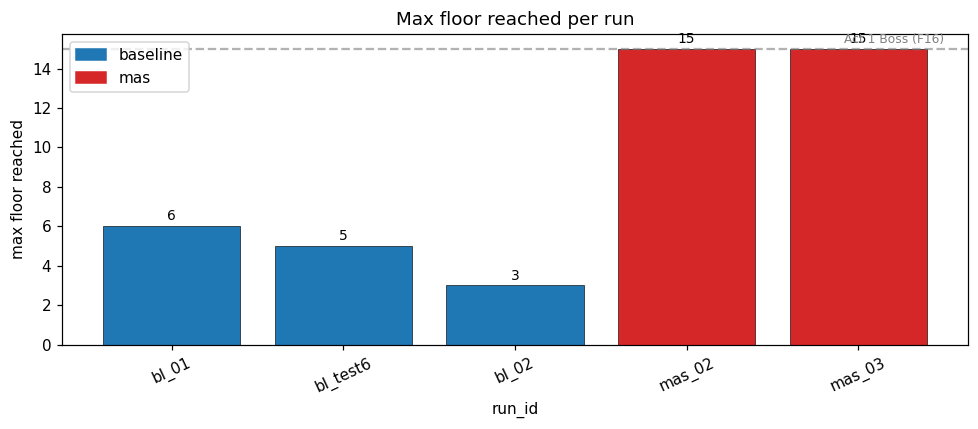

In [5]:
# Cell 4 — max floor reached by run
fig, ax = plt.subplots(figsize=(9,4))
df_sorted = df_summary.sort_values(['system','max_floor'], ascending=[True, False]).reset_index(drop=True)
colors = [SYS_COLOR[s] for s in df_sorted['system']]
bars = ax.bar(df_sorted['run_id'], df_sorted['max_floor'], color=colors, edgecolor='black', linewidth=0.4)
for x, v in zip(df_sorted['run_id'], df_sorted['max_floor']):
    ax.text(x, v + 0.3, str(int(v)), ha='center', fontsize=9)
ax.axhline(15, ls='--', c='gray', alpha=0.6)
ax.text(len(df_sorted)-0.5, 15.3, 'Act 1 Boss (F16)', fontsize=8, color='gray', ha='right')
ax.set_xlabel('run_id'); ax.set_ylabel('max floor reached'); ax.set_title('Max floor reached per run')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=SYS_COLOR['baseline'], label='baseline'),
                   Patch(color=SYS_COLOR['mas'], label='mas')], loc='upper left')
plt.xticks(rotation=25); plt.tight_layout(); plt.show()

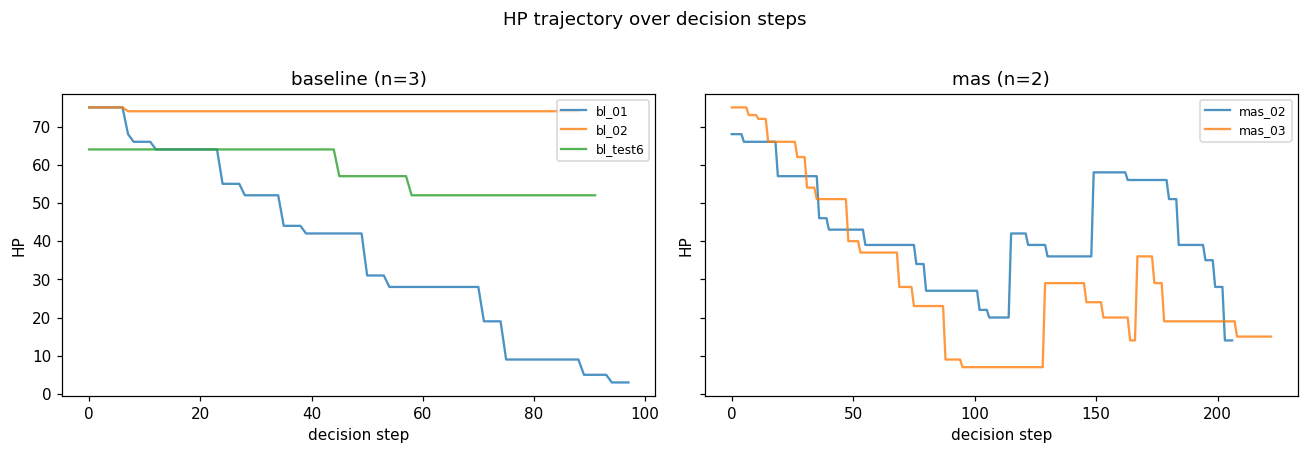

In [6]:
# Cell 5 — HP trajectory over decision steps (per run)
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
for ax, sys_ in zip(axes, ['baseline','mas']):
    sub = df_steps[df_steps['system']==sys_]
    for rid, g in sub.groupby('run_id'):
        ax.plot(g['step'], g['hp'], alpha=0.8, label=rid)
    ax.set_title(f'{sys_} (n={sub["run_id"].nunique()})')
    ax.set_xlabel('decision step'); ax.set_ylabel('HP')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle('HP trajectory over decision steps', y=1.02)
plt.tight_layout(); plt.show()

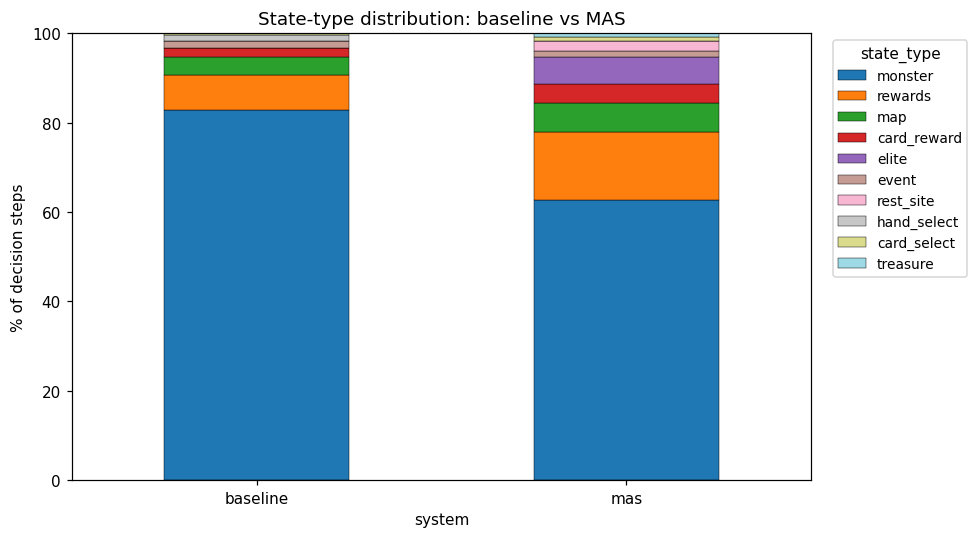

system       baseline   mas
state_type                 
monster          82.8  62.8
rewards           7.9  15.1
map               3.9   6.5
card_reward       2.2   4.2
elite             0.0   6.0
event             1.4   1.4
rest_site         0.0   2.1
hand_select       1.4   0.0
card_select       0.4   0.9
treasure          0.0   0.9


In [7]:
# Cell 6 — state_type time share: baseline vs MAS
share = df_steps.groupby(['system','state_type']).size().unstack(fill_value=0)
share_pct = share.div(share.sum(axis=1), axis=0) * 100
# order columns by overall frequency
col_order = share_pct.sum(axis=0).sort_values(ascending=False).index
share_pct = share_pct[col_order]

ax = share_pct.plot(kind='bar', stacked=True, figsize=(9,5), colormap='tab20', edgecolor='black', linewidth=0.3)
ax.set_ylabel('% of decision steps'); ax.set_title('State-type distribution: baseline vs MAS')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize=9, title='state_type')
plt.tight_layout(); plt.show()
print(share_pct.round(1).T)

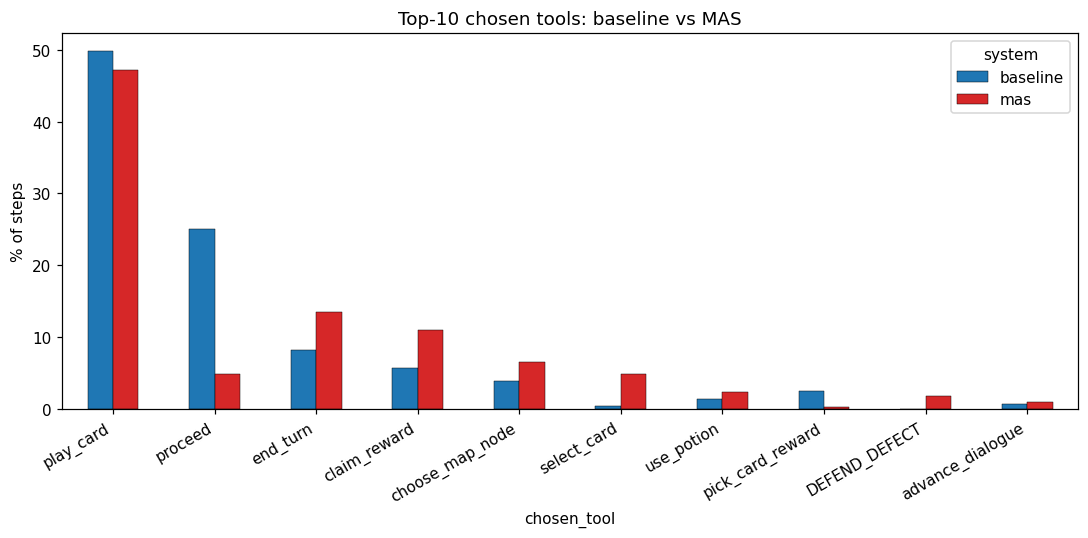

system            baseline   mas
chosen_tool                     
play_card             49.8  47.2
proceed               25.1   4.9
end_turn               8.2  13.5
claim_reward           5.7  10.9
choose_map_node        3.9   6.5
select_card            0.4   4.9
use_potion             1.4   2.3
pick_card_reward       2.5   0.2
DEFEND_DEFECT          0.0   1.9
advance_dialogue       0.7   0.9


In [8]:
# Cell 7 — chosen_tool frequency: baseline vs MAS (top 10 tools)
tool_counts = df_steps.groupby(['system','chosen_tool']).size().unstack(fill_value=0)
tool_pct = tool_counts.div(tool_counts.sum(axis=1), axis=0) * 100
top_tools = tool_pct.sum(axis=0).sort_values(ascending=False).head(10).index
tool_top = tool_pct[top_tools]

ax = tool_top.T.plot(kind='bar', figsize=(10,5), color=[SYS_COLOR['baseline'], SYS_COLOR['mas']],
                     edgecolor='black', linewidth=0.3)
ax.set_ylabel('% of steps'); ax.set_xlabel('chosen_tool')
ax.set_title('Top-10 chosen tools: baseline vs MAS')
ax.legend(title='system')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print(tool_top.round(1).T)

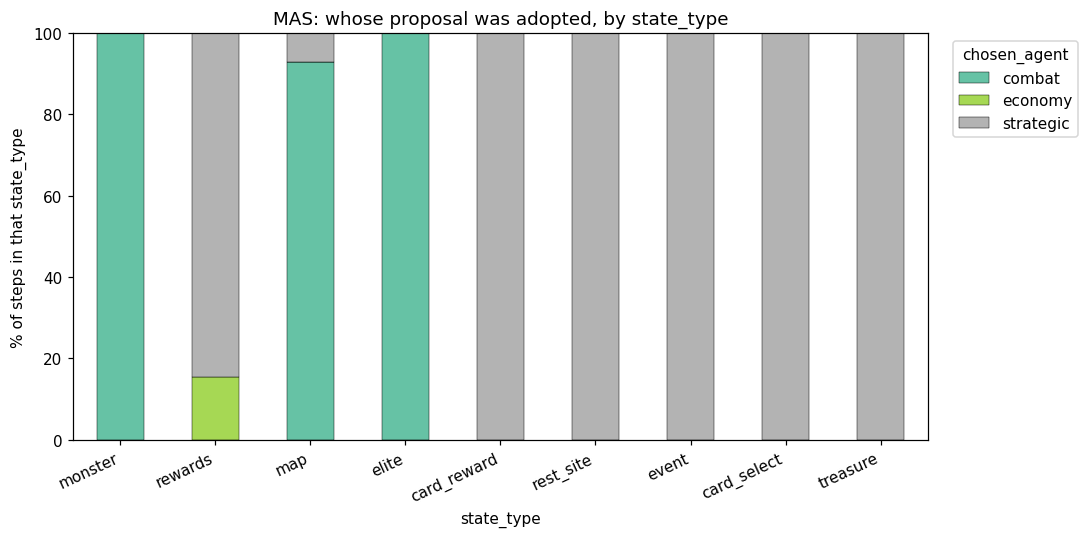


Overall MAS agent adoption:
chosen_agent
combat       322
strategic     98
economy       10

Agreement rate (all agents same action):
agreement
True     96.7
False     3.3


In [9]:
# Cell 8 — MAS agent adoption: which agent's proposal was chosen, by state_type
mas = df_steps[df_steps['system']=='mas'].copy()
if len(mas) == 0:
    print('no MAS rows in df_steps')
else:
    adop = mas.groupby(['state_type','chosen_agent']).size().unstack(fill_value=0)
    adop_pct = adop.div(adop.sum(axis=1), axis=0) * 100
    # order rows by sample size
    row_order = adop.sum(axis=1).sort_values(ascending=False).index
    adop_pct = adop_pct.loc[row_order]

    ax = adop_pct.plot(kind='bar', stacked=True, figsize=(10,5), colormap='Set2', edgecolor='black', linewidth=0.3)
    ax.set_ylabel('% of steps in that state_type'); ax.set_xlabel('state_type')
    ax.set_title('MAS: whose proposal was adopted, by state_type')
    ax.legend(title='chosen_agent', bbox_to_anchor=(1.02,1.0), loc='upper left')
    plt.xticks(rotation=25, ha='right'); plt.tight_layout(); plt.show()

    print('\nOverall MAS agent adoption:')
    print(mas['chosen_agent'].value_counts(dropna=False).to_string())
    print('\nAgreement rate (all agents same action):')
    print(mas['agreement'].value_counts(normalize=True).mul(100).round(1).to_string())